## Income Classification

### Objective

Build a model that can predict if a person's income is under or over $50,000. Various models will be built and compared - decision tree, random forest, logistic regression


### Data Dictionary

The data contains characteristics of the people

* age: age of a person 
* workclass: where person works 
* fnlwgt: weight of demographic characteristics - people with similar weights will have similar demographic characteristics
* education: education level of a person
* education-num: number of years of education a person has
* marital-status: marital status of the person
* occupation: occupation category of a person
* relationship : 
* race: race of the person
* sex: sex of the person
* capital-gain: investment gain of the person other than salary 
* capital-loss: loss from investments
* hours-per-week: number of hours a person works
* native-country: country the person lives in
* salary: >50K, <=50K (dependent variable, the salary is in Dollars per year)

### Loading Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


### Load data

In [2]:
df = pd.read_csv("income.csv")

In [3]:
data = df.copy()

## Data Overview

In [4]:
df.sample(20)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
13855,23,Private,210474,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Female,0,0,40,United-States,<=50K
38678,49,Private,168262,10th,6,Divorced,Other-service,Not-in-family,White,Male,0,0,48,United-States,<=50K
13359,27,Private,177955,Bachelors,13,Never-married,Tech-support,Own-child,White,Female,0,0,40,Mexico,<=50K
2166,43,Self-emp-not-inc,451019,Bachelors,13,Never-married,Sales,Own-child,White,Male,0,0,35,United-States,<=50K
25886,22,Private,100345,Bachelors,13,Never-married,Craft-repair,Not-in-family,White,Male,13550,0,55,United-States,>50K
3801,23,Private,275357,Some-college,10,Never-married,Other-service,Not-in-family,White,Female,0,0,35,United-States,<=50K
6972,39,Self-emp-not-inc,122852,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,45,United-States,>50K
40162,17,Private,178953,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
48301,21,Private,211968,Some-college,10,Never-married,Sales,Own-child,White,Female,0,1762,28,United-States,<=50K
39541,37,Private,178948,Bachelors,13,Married-civ-spouse,Exec-managerial,Wife,White,Female,7688,0,45,United-States,>50K


There are ?s in the workclass, occupation, and native-country

In [5]:
df.shape

(48842, 15)

* 48842 rows and 15 columns 

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


Observation:
- numeric features - age, fnlwgt, education-num, capital-gain, capital-loss, hours-per-week
- object features - workclass, education, marital-status, occupation, relationship, race, gender, native-country, income

In [7]:
# Check for duplicate values in the data
df.duplicated().sum()

52

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,48842.0,38.643585,13.710510,17.0,28.0,37.0,48.0,90.0
fnlwgt,48842.0,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
educational-num,48842.0,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
capital-gain,48842.0,1079.067626,7452.019058,0.0,0.0,0.0,0.0,99999.0
capital-loss,48842.0,87.502314,403.004552,0.0,0.0,0.0,0.0,4356.0
hours-per-week,48842.0,40.422382,12.391444,1.0,40.0,40.0,45.0,99.0


Observations:
- Age ranges from 17 - 90
- fnlwgt ranges from 12,285 - 1,490,400
- educational-num ranges from 1 - 16
- capital gains ranges from 0 - 99,999
- capital loss ranges from 0 - 4356
- hours per week rang from 1 - 99

Note: for this assignment, we are removing fnlwgt, capital-gain, and capital-loss

In [9]:
df = df.drop(['fnlwgt'], axis=1)

In [10]:
df = df.drop(['capital-gain'], axis=1)

In [11]:
df = df.drop(['capital-loss'], axis=1)

In [12]:
df.head(5)

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,40,United-States,>50K
4,18,?,Some-college,10,Never-married,?,Own-child,White,Female,30,United-States,<=50K


## Data Preprocessing

#### Delete duplicate data

In [13]:
df.shape

(48842, 12)

In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(41082, 12)

#### Explore the features with '?' values

In [16]:
df[df["workclass"] == '?']

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income
4,18,?,Some-college,10,Never-married,?,Own-child,White,Female,30,United-States,<=50K
6,29,?,HS-grad,9,Never-married,?,Unmarried,Black,Male,40,United-States,<=50K
13,58,?,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,35,United-States,<=50K
22,72,?,7th-8th,4,Divorced,?,Not-in-family,White,Female,6,United-States,<=50K
35,65,?,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,?,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,55,United-States,>50K
48812,30,?,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,99,United-States,<=50K
48820,71,?,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,10,United-States,>50K
48822,41,?,HS-grad,9,Separated,?,Not-in-family,Black,Female,32,United-States,<=50K


* appears that when workclass is ? so is occupation and native-country is United-States

In [17]:
df[df["occupation"] == '?']

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income
4,18,?,Some-college,10,Never-married,?,Own-child,White,Female,30,United-States,<=50K
6,29,?,HS-grad,9,Never-married,?,Unmarried,Black,Male,40,United-States,<=50K
13,58,?,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,35,United-States,<=50K
22,72,?,7th-8th,4,Divorced,?,Not-in-family,White,Female,6,United-States,<=50K
35,65,?,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,?,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,55,United-States,>50K
48812,30,?,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,99,United-States,<=50K
48820,71,?,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,10,United-States,>50K
48822,41,?,HS-grad,9,Separated,?,Not-in-family,Black,Female,32,United-States,<=50K


* appears that when occupation is ? so is workclass and native-country is United-States

In [18]:
df[df["native-country"] == '?']

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,hours-per-week,native-country,income
19,40,Private,Doctorate,16,Married-civ-spouse,Prof-specialty,Husband,Asian-Pac-Islander,Male,45,?,>50K
65,41,Private,Bachelors,13,Never-married,Other-service,Not-in-family,White,Female,40,?,<=50K
83,44,Self-emp-inc,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,50,?,>50K
188,34,State-gov,Bachelors,13,Married-spouse-absent,Farming-fishing,Not-in-family,Black,Male,40,?,<=50K
253,42,Federal-gov,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Male,40,?,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
48730,44,Self-emp-inc,Masters,14,Married-civ-spouse,Sales,Husband,White,Male,50,?,>50K
48750,58,Self-emp-inc,Doctorate,16,Never-married,Prof-specialty,Not-in-family,White,Female,99,?,<=50K
48773,42,Self-emp-not-inc,HS-grad,9,Divorced,Sales,Own-child,White,Male,50,?,<=50K
48791,39,Private,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,45,?,>50K


In [19]:
df[df["workclass"] == "?"]["occupation"].value_counts()

occupation
?    2370
Name: count, dtype: int64

In [20]:
df[df["workclass"] == "?"]["native-country"].value_counts()

native-country
United-States                 2102
Mexico                          48
?                               46
Canada                          19
South                           14
Germany                         13
Philippines                     12
Taiwan                          10
China                            9
Puerto-Rico                      9
El-Salvador                      8
England                          8
Poland                           6
Haiti                            6
Cuba                             5
Dominican-Republic               5
Portugal                         5
Italy                            5
India                            4
Jamaica                          3
Iran                             3
Columbia                         3
Vietnam                          3
Japan                            3
Guatemala                        2
France                           2
Cambodia                         2
Hong                             2
Laos 

In [21]:
df[df["occupation"] == "?"]["workclass"].value_counts()

workclass
?               2370
Never-worked      10
Name: count, dtype: int64

In [22]:
df[df["occupation"] == "?"]["native-country"].value_counts()

native-country
United-States                 2112
Mexico                          48
?                               46
Canada                          19
South                           14
Germany                         13
Philippines                     12
Taiwan                          10
China                            9
Puerto-Rico                      9
El-Salvador                      8
England                          8
Poland                           6
Haiti                            6
Cuba                             5
Dominican-Republic               5
Portugal                         5
Italy                            5
India                            4
Jamaica                          3
Iran                             3
Columbia                         3
Vietnam                          3
Japan                            3
Guatemala                        2
France                           2
Cambodia                         2
Hong                             2
Laos 

In [23]:
df[df["native-country"] == "?"]["workclass"].value_counts()

workclass
Private             595
Self-emp-not-inc     66
Self-emp-inc         49
?                    46
Local-gov            36
State-gov            35
Federal-gov          26
Name: count, dtype: int64

In [24]:
df[df["native-country"] == "?"]["occupation"].value_counts()

occupation
Prof-specialty       163
Other-service        114
Exec-managerial      101
Sales                 95
Craft-repair          92
Adm-clerical          71
Machine-op-inspct     52
?                     46
Transport-moving      39
Handlers-cleaners     26
Tech-support          26
Farming-fishing       10
Priv-house-serv       10
Protective-serv        7
Armed-Forces           1
Name: count, dtype: int64

#### Observations:
* strong pattern when workclass = ? then occupation = ?
* no strong pattern with workclass and occupation when native-country = ?
* update ? with 'Unknown' for more exploration

In [25]:
df.loc[df['workclass'] == '?', ['workclass']] = 'Unknown'
df.loc[df['occupation'] == '?', ['occupation']] = 'Unknown'
df.loc[df['native-country'] == '?', ['native-country']] = 'Unknown'

#### Find the value counts for the object features

In [26]:
# frequency for categorical fields 
category_col =['workclass', 'education', 'marital-status', 'occupation',
               'relationship', 'race', 'gender', 'native-country', 'income'] 
for c in category_col:
    print (c)
    print (df[c].value_counts())

workclass
workclass
Private             27155
Self-emp-not-inc     3678
Local-gov            2944
Unknown              2370
State-gov            1914
Self-emp-inc         1608
Federal-gov          1382
Without-pay            21
Never-worked           10
Name: count, dtype: int64
education
education
HS-grad         12469
Some-college     8921
Bachelors        6559
Masters          2386
Assoc-voc        1926
11th             1575
Assoc-acdm       1553
10th             1262
7th-8th           923
Prof-school       774
9th               734
12th              617
Doctorate         565
5th-6th           496
1st-4th           241
Preschool          81
Name: count, dtype: int64
marital-status
marital-status
Married-civ-spouse       18128
Never-married            13118
Divorced                  6168
Separated                 1509
Widowed                   1495
Married-spouse-absent      627
Married-AF-spouse           37
Name: count, dtype: int64
occupation
occupation
Prof-specialty       5441
E

#### Check for outliers in the numeric columns

<Axes: ylabel='age'>

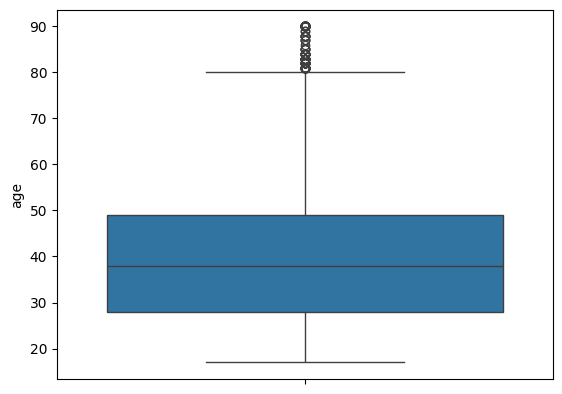

In [27]:
sns.boxplot(data=df, y='age')

<Axes: ylabel='educational-num'>

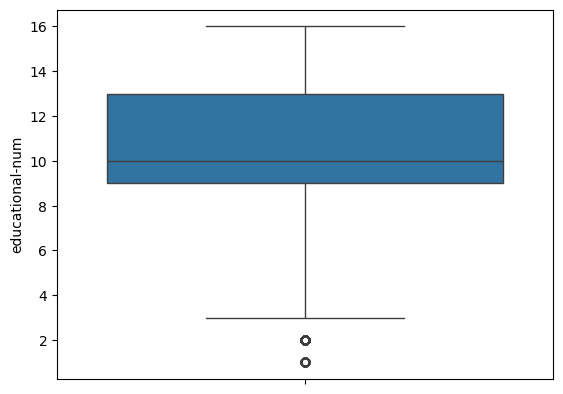

In [28]:
sns.boxplot(data=df, y='educational-num')

<Axes: ylabel='hours-per-week'>

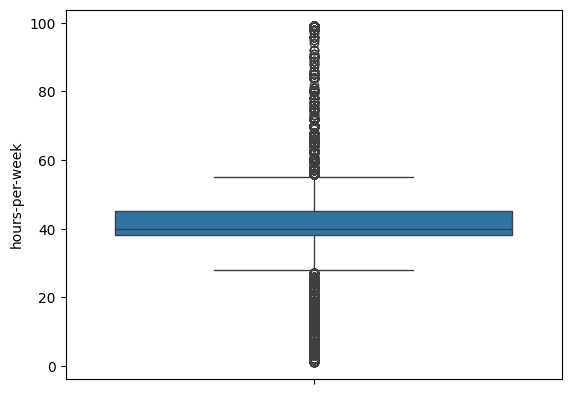

In [29]:
sns.boxplot(data=df, y='hours-per-week')

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'educational-num'}>],
       [<Axes: title={'center': 'hours-per-week'}>, <Axes: >]],
      dtype=object)

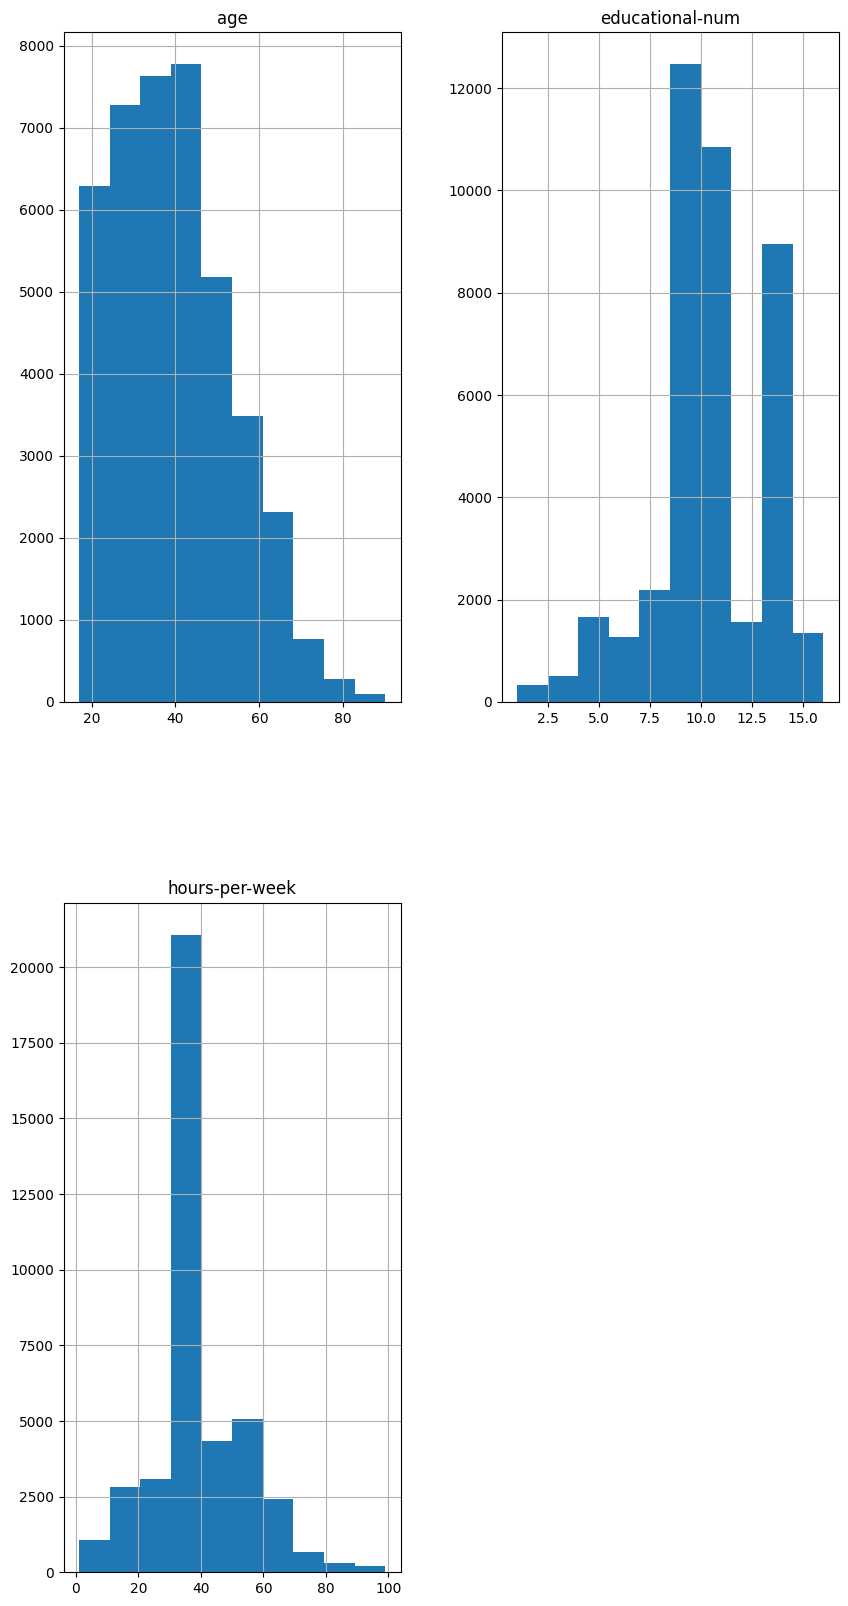

In [30]:
df.hist(figsize=(10,20))

At this point we will not adjust any of the outliers

## EDA

In [31]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [32]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [33]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [34]:
### function to plot distributions wrt target
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

### Univariate Analysis

#### COMPLETE: explore the individual features using histogram_boxplot for numeric features and labeled_barplot for object features providing ample observations

#### Numerical Columns - age, educational-num, hours-per-week

In [35]:
df.age.describe()

count    41082.000000
mean        39.475780
std         13.864426
min         17.000000
25%         28.000000
50%         38.000000
75%         49.000000
max         90.000000
Name: age, dtype: float64

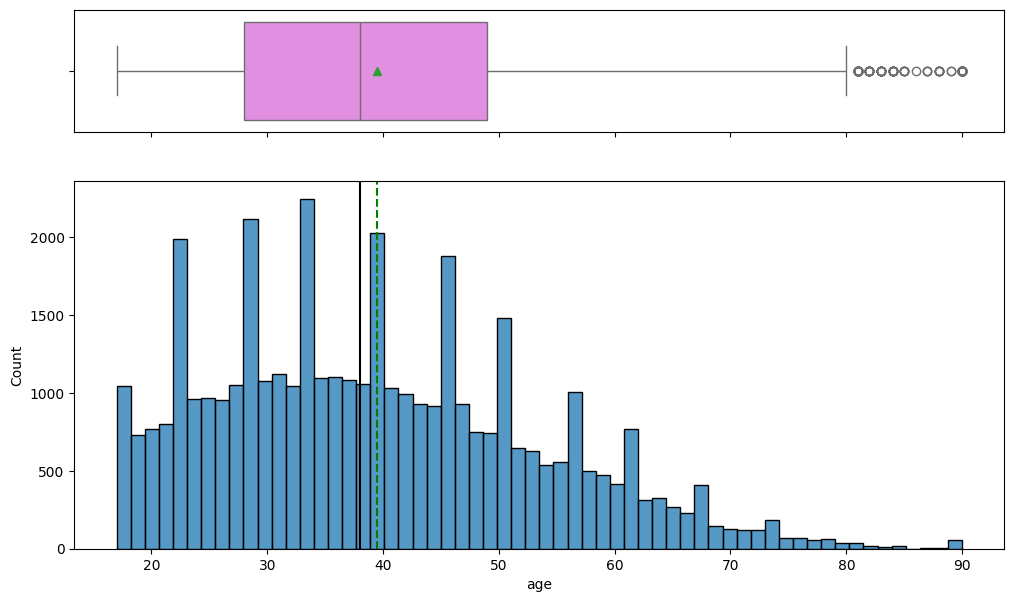

In [36]:
histogram_boxplot(df, 'age')

In [37]:
df['age'].mode()

0    33
Name: age, dtype: int64

<b>Observations:</b>
<ul>
    <li>Age: Mean=39.48 Mode=33 Median=38 Range=17-90</li>
    <li>As would be expected for age, the distribution is right-skewed</li>
    <li>There are strange, intermittent, data points where there is a sharp uptick in count of a given value, likely due to grouping of multiple values in each point</li>
</ul>

In [38]:
df['educational-num'].describe()

count    41082.000000
mean        10.065722
std          2.666196
min          1.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         16.000000
Name: educational-num, dtype: float64

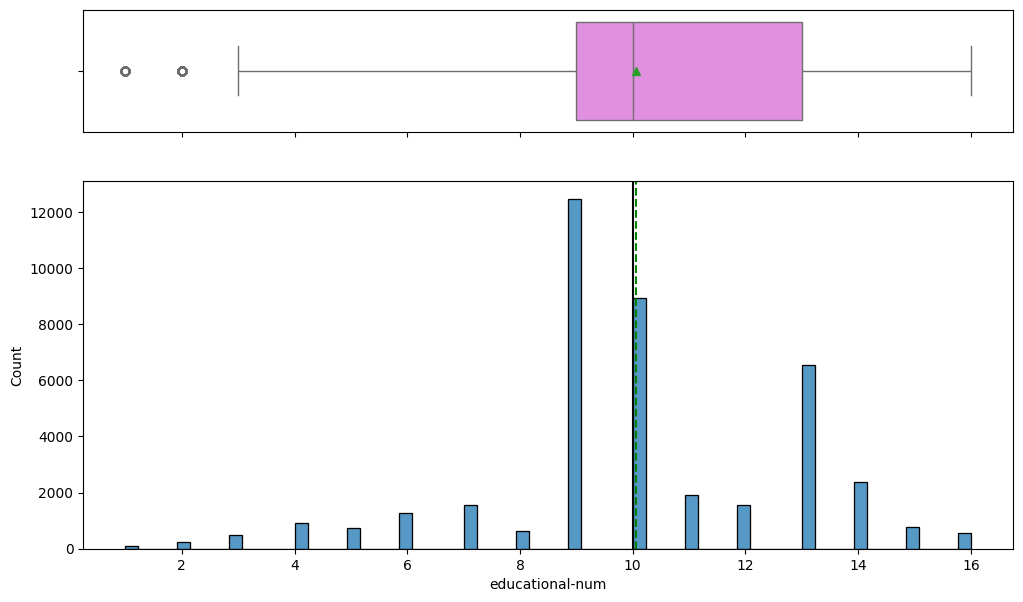

In [39]:
histogram_boxplot(df, 'educational-num')

In [40]:
df['educational-num'].mode()

0    9
Name: educational-num, dtype: int64

<b>Observations:</b>
<ul>
    <li>Educational-num: Mean=10.07 Mode=9 Median=10 Range=1-16</li>
    <li>Data is heavily skewed left, with the majority of values being in the center</li>
    <li>Mean and median are very close, but mean > median</li>
</ul>

In [41]:
df['hours-per-week'].describe()

count    41082.000000
mean        40.578380
std         12.992359
min          1.000000
25%         38.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64

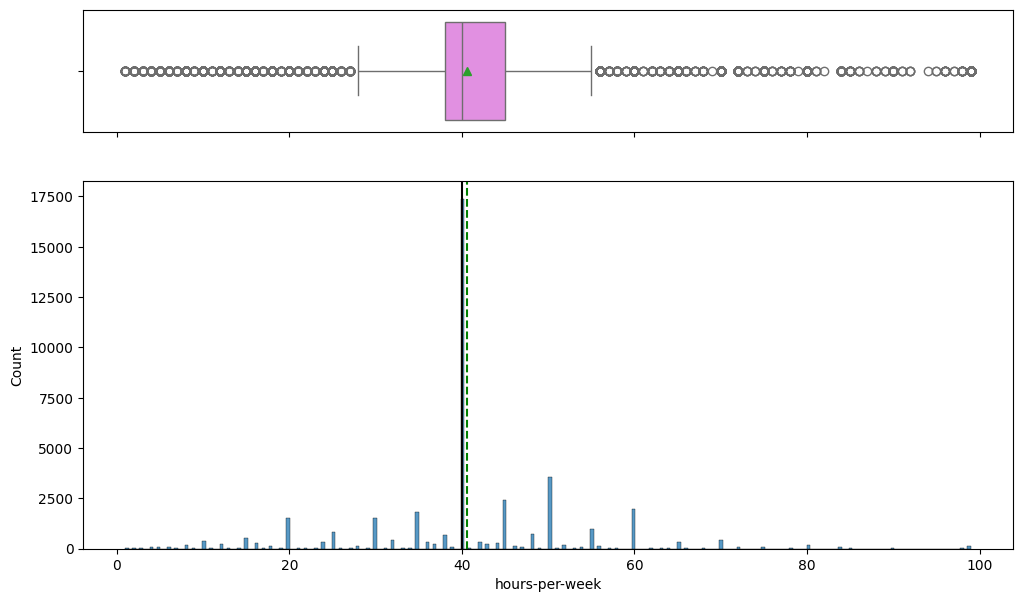

In [42]:
histogram_boxplot(df, 'hours-per-week')

In [43]:
df['hours-per-week'].mode()

0    40
Name: hours-per-week, dtype: int64

<b>Observations:</b>
<ul>
    <li>Hours-per-week: Mean=40.59 Mode=40 Median=40 Range=1-99</li>
    <li>Mean, median, and mode are practically the same, with the vast majority of values being 40</li>
    <li>Distribution is mostly normal</li>
</ul>

#### Categorical Columns - workclass, education, marital-status, occupation, relationship, race, sex, native-country

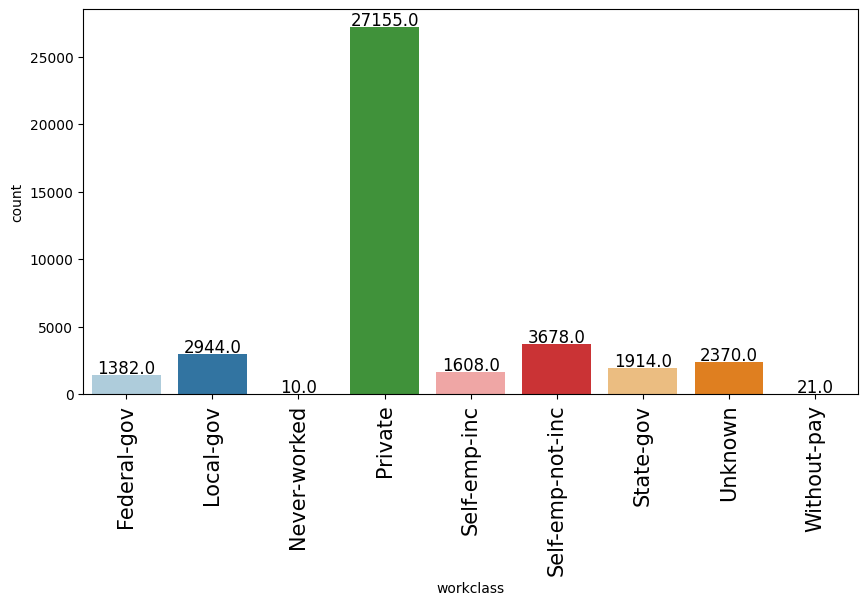

In [44]:
labeled_barplot(df, 'workclass')

<b>Observations:</b>
<ul>
    <li>The vast majority of rows have a workclass of 'private'</li>
    <li>Other values are relatively similar, in terms of count</li>
    <li>'Never-worked' and 'without-pay' are the only exceptions to the above</li>
</ul>

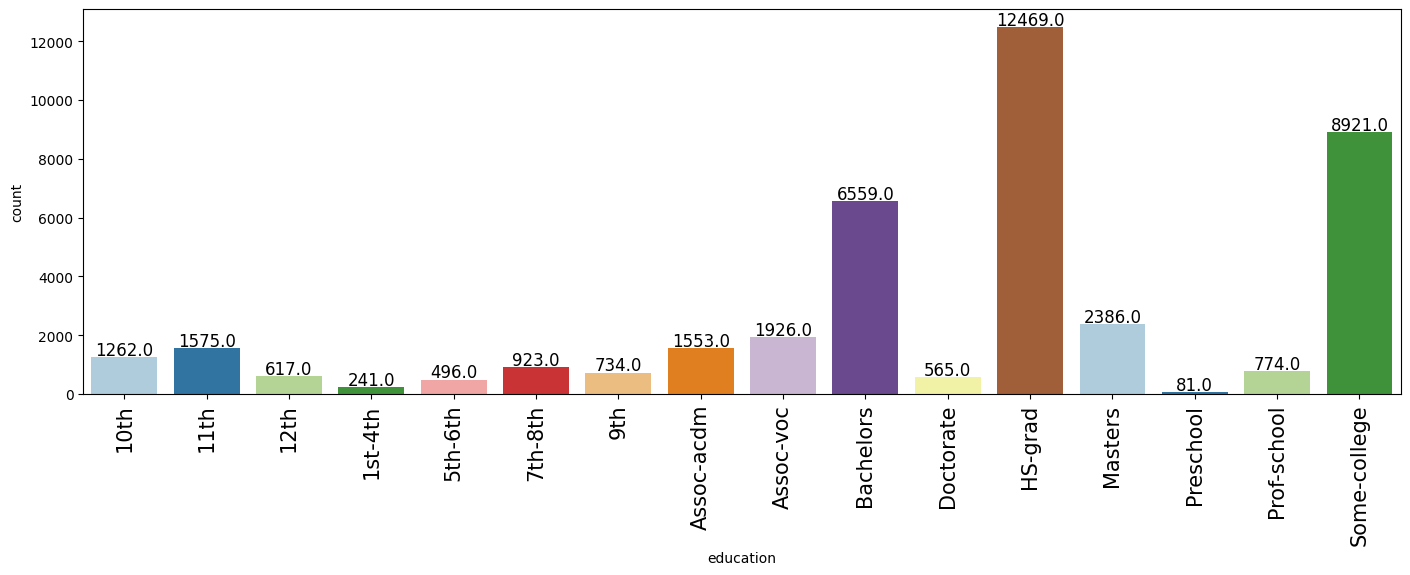

In [45]:
labeled_barplot(df, 'education')

<b>Observations:</b>
<ul>
    <li>By far, the most common value is 'hs-grad', followed by 'some-college', then 'bachelors'</li>
    <li>It seems as if more rows have some amount of post-highschool education than those that don't</li>
</ul>

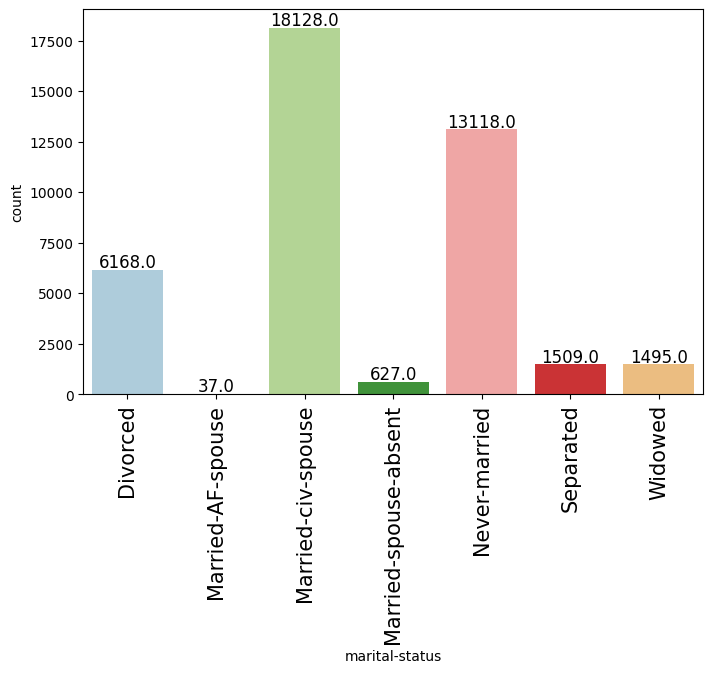

In [46]:
labeled_barplot(df, 'marital-status')

<b>Observations:</b>
<ul>
    <li>Most common value is 'married-civ-spouse', closely followed by 'never-married'</li>
    <li>'Divorced' is also relatively common, but not nearly as common as the previous two</li>
</ul>

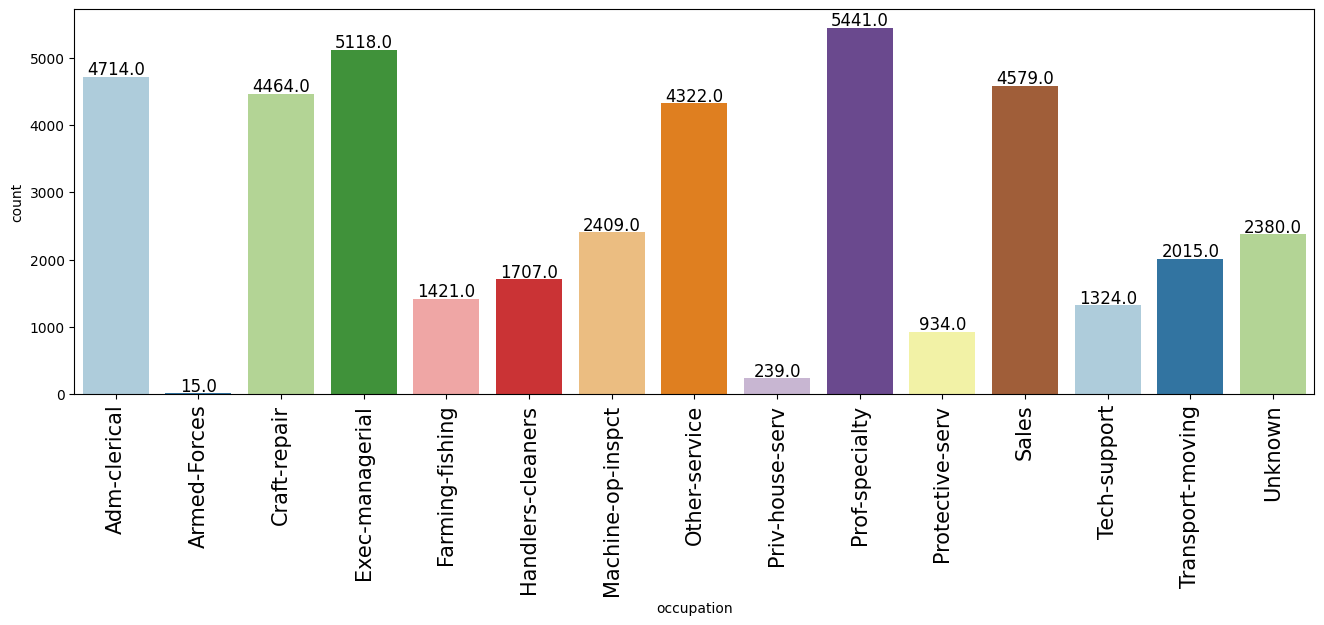

In [47]:
labeled_barplot(df, 'occupation')

<b>Observations:</b>
<ul>
    <li>There are no particular values that obviously stand out as the most common</li>
    <li>The 6 most common are all similar, in terms of frequency, those being 'adm-clerical', 'craft-repair', 'exec-managerial', 'other-service', 'prof-specialty', and 'sales'</li>
</ul>

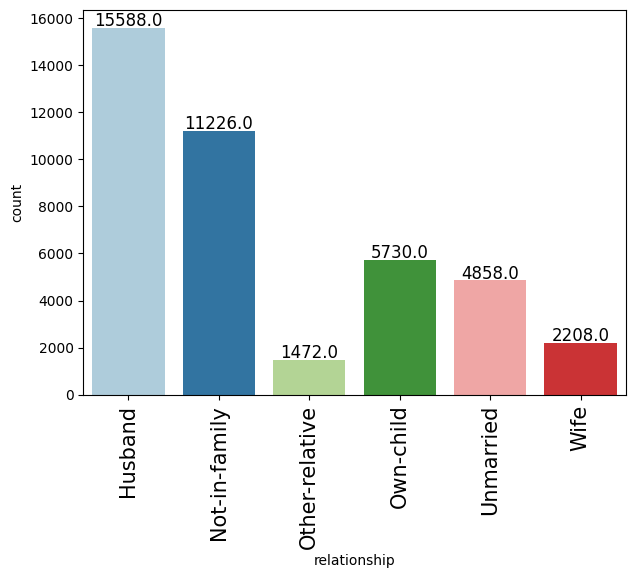

In [48]:
labeled_barplot(df, 'relationship')

<b>Observations:</b>
<ul>
    <li>The most common value, by far, is 'husband', followed by 'not-in-family'</li>
    <li>A significantly larger number of rows classify as 'own-child' or 'unmarried', rather than 'wife'</li>
    <li>'Husband' is roughly 7 times more common than 'wife'</li>
</ul>

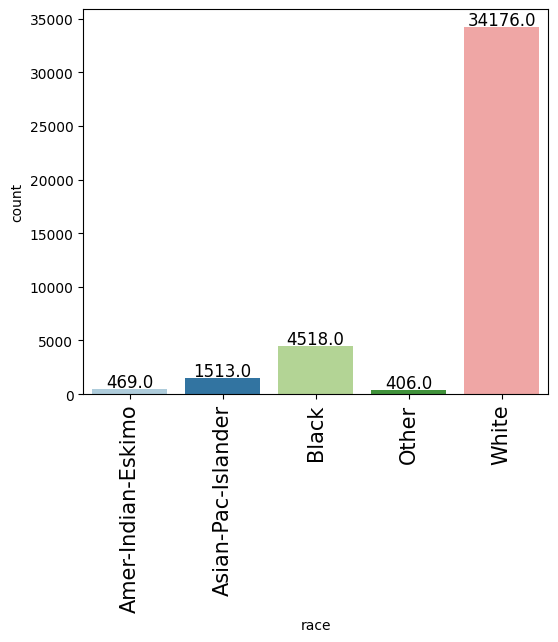

In [49]:
labeled_barplot(df, 'race')

<b>Observations:</b>
<ul>
    <li>'White' is, by far, the most common value for race</li>
    <li>'Black' is the next most common, with the others being relatively similar</li>
    <li>'White' is roughly 7.5 times more common than 'black'</li>
</ul>

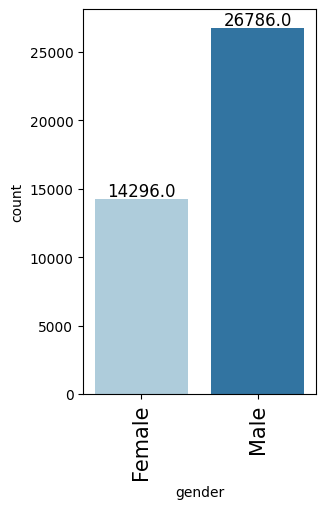

In [50]:
labeled_barplot(df, 'gender')

<b>Observation:</b> 'Male' is almost twice as common as 'female'

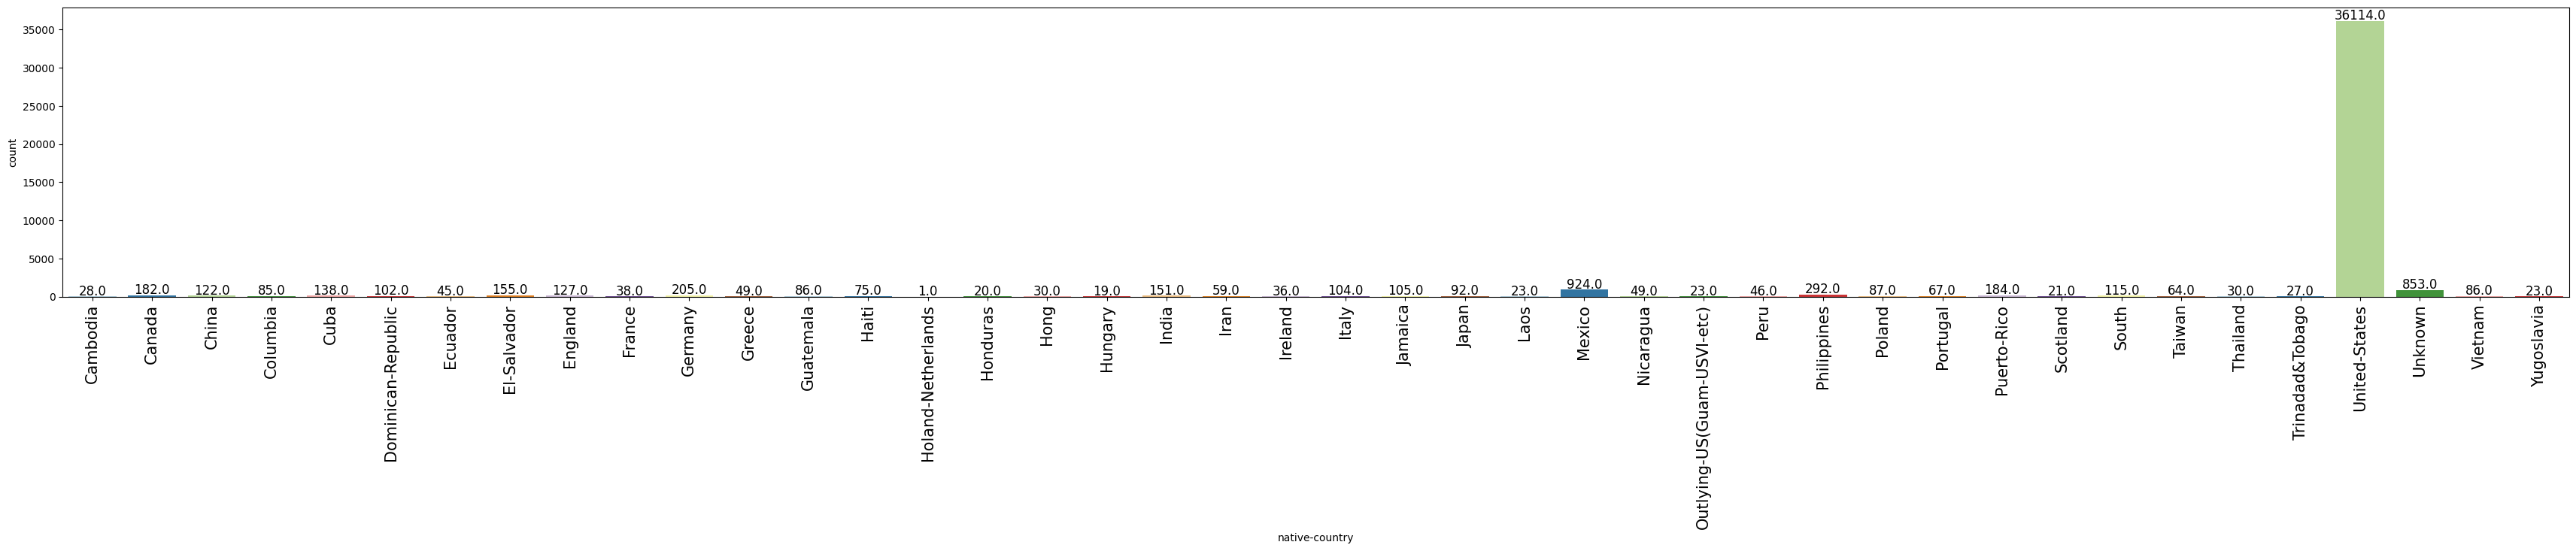

In [51]:
labeled_barplot(df, 'native-country')

<b>Observations:</b>
<ul>
    <li>United States is, by far, the most common value for native-country, with no other single value standing out</li>
</ul>

### Bivariate Analysis

#### COMPLETE: explore the relationships/patterns between features using heatmap and pairplot. Also use stacked_barplot and distribution_plot_wrt_target to compare the independent features to income

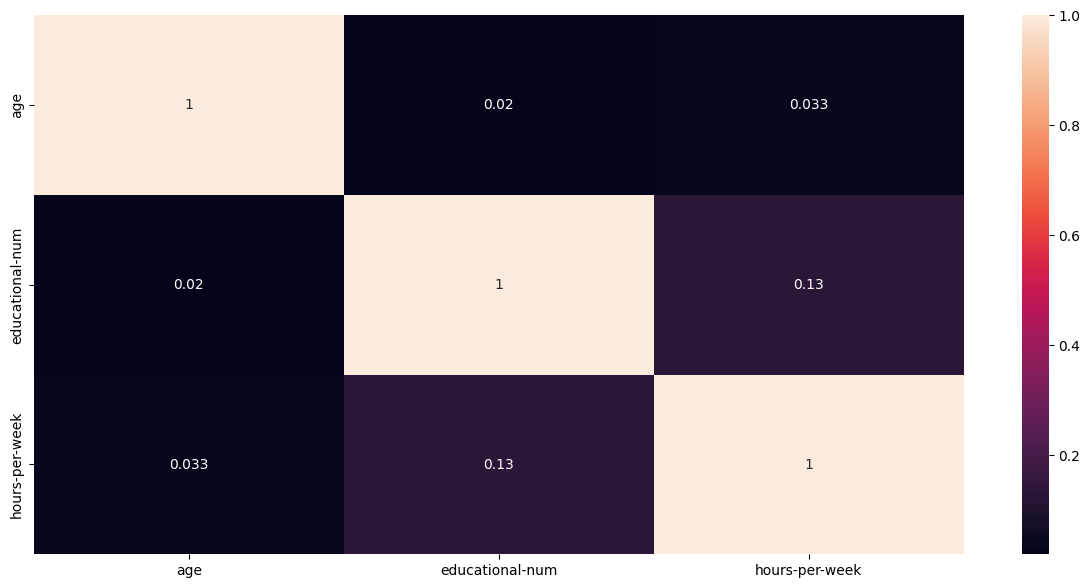

In [52]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True);

<b>Observation:</b> There isn't anything particularly noteworthy or surprising here, as there is high variance in age, educational-num, and hours-per-week.

#### Visualizing age correlation to income

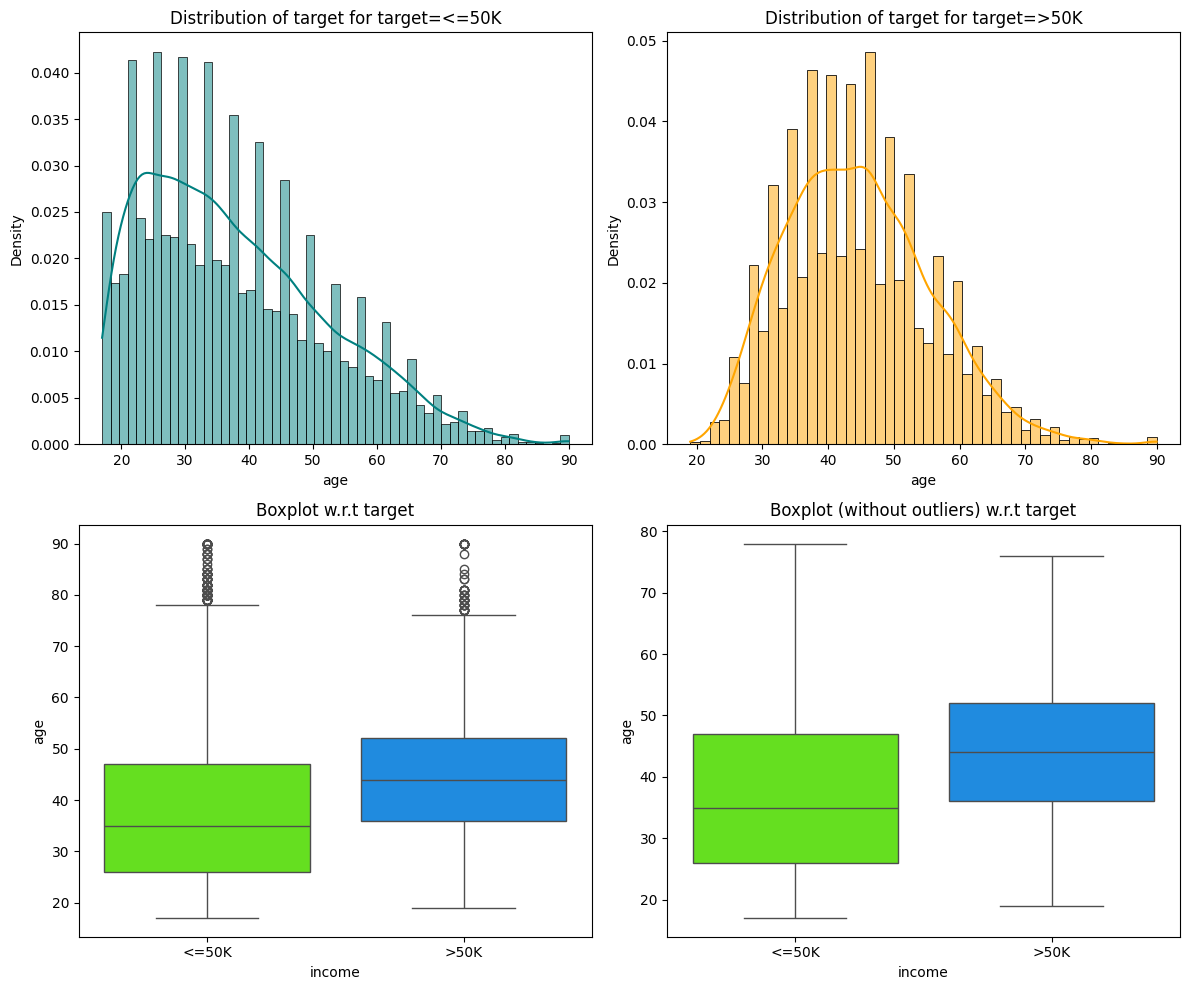

In [53]:
distribution_plot_wrt_target(df, 'age', 'income')

<b>Observation:</b> It appears as though individuals with incomes >50k are a higher age, on average, compared to those with incomes <=50k.

#### Visualizing workclass correlation with income

income            <=50K  >50K    All
workclass                           
All               31472  9610  41082
Private           21558  5597  27155
Self-emp-not-inc   2665  1013   3678
Self-emp-inc        743   865   1608
Local-gov          2099   845   2944
Federal-gov         856   526   1382
State-gov          1403   511   1914
Unknown            2119   251   2370
Without-pay          19     2     21
Never-worked         10     0     10
------------------------------------------------------------------------------------------------------------------------


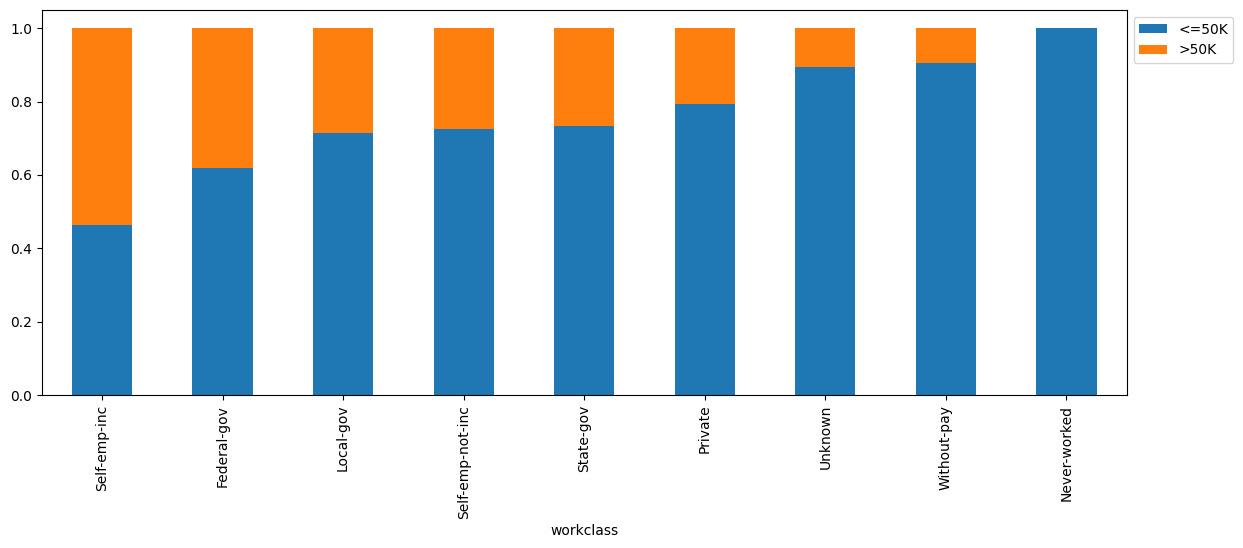

In [54]:
stacked_barplot(df, 'workclass', 'income')

<b>Observations:</b>
<ul>
    <li>The only workclass that has a larger number of individuals with incomes above 50k than below is 'self-emp-inc'.</li>
    <li>The rest of the values have a considerably greater number of individuals with incomes below 50k.</li>
</ul>

#### Visualizing education correlation with income

income        <=50K  >50K    All
education                       
All           31472  9610  41082
Bachelors      4058  2501   6559
HS-grad       10523  1946  12469
Some-college   7201  1720   8921
Masters        1138  1248   2386
Prof-school     216   558    774
Assoc-voc      1446   480   1926
Doctorate       161   404    565
Assoc-acdm     1155   398   1553
11th           1484    91   1575
10th           1183    79   1262
7th-8th         862    61    923
12th            570    47    617
9th             693    41    734
5th-6th         469    27    496
1st-4th         233     8    241
Preschool        80     1     81
------------------------------------------------------------------------------------------------------------------------


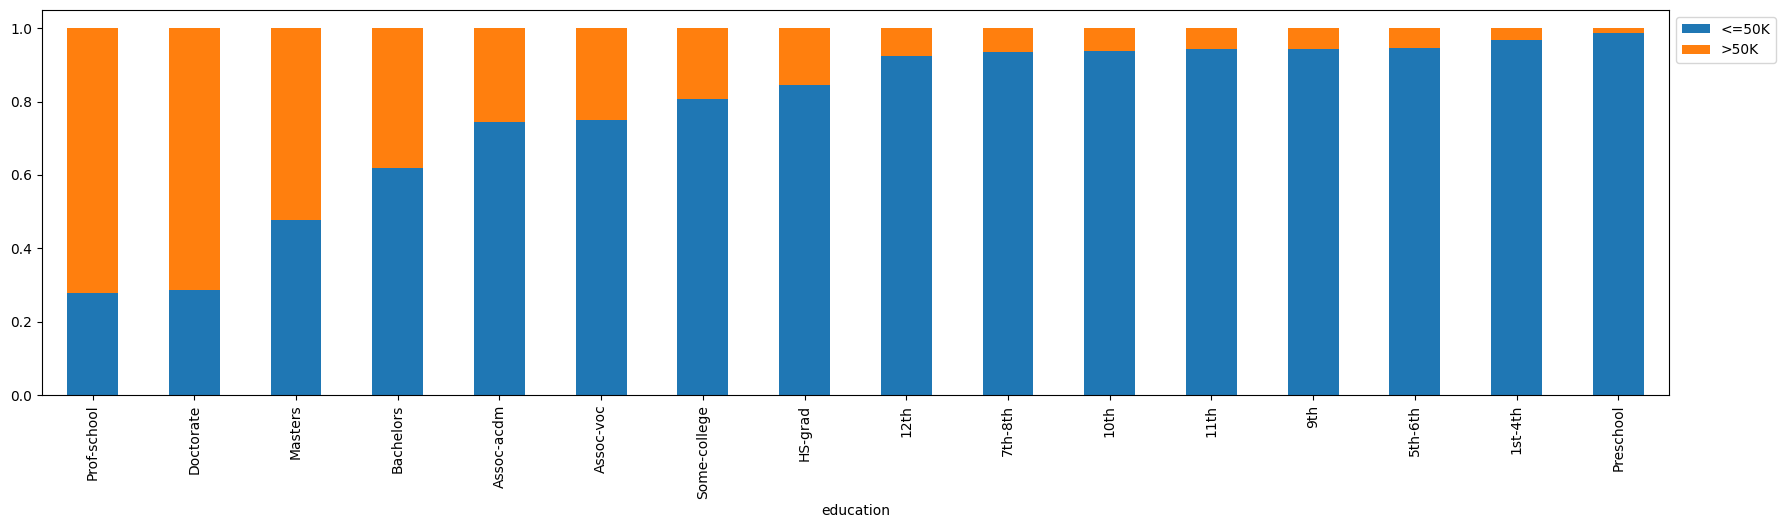

In [55]:
stacked_barplot(df, 'education', 'income')

<b>Observation:</b> There is a continuously greater number of individuals with incomes above 50k, as educations become more extensive.

#### Visualizing education-num correlation with income

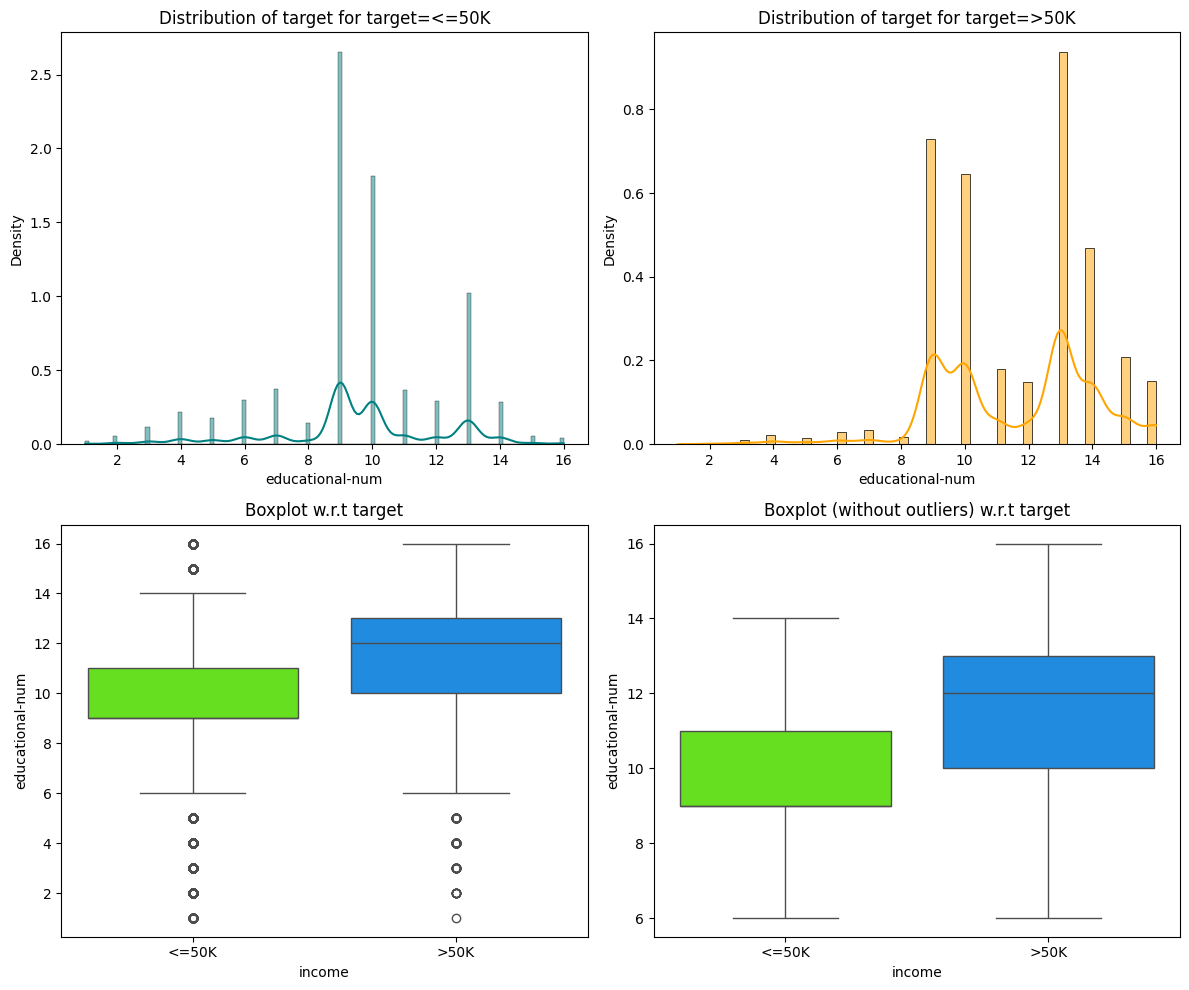

In [56]:
distribution_plot_wrt_target(df, 'educational-num', 'income')

<b>Observation:</b> Upward trend of income, as education becomes higher, is consistent with the categorical version of this column.

#### Visualizing marital-status correlation to income

income                 <=50K  >50K    All
marital-status                           
All                    31472  9610  41082
Married-civ-spouse     10195  7933  18128
Never-married          12400   718  13118
Divorced                5507   661   6168
Widowed                 1368   127   1495
Separated               1410    99   1509
Married-spouse-absent    569    58    627
Married-AF-spouse         23    14     37
------------------------------------------------------------------------------------------------------------------------


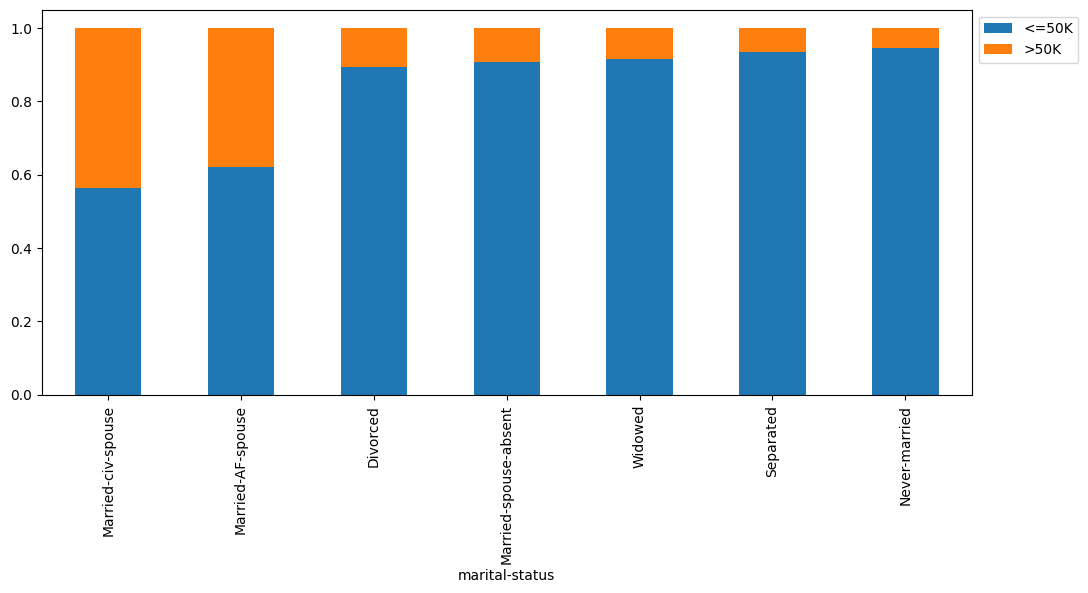

In [57]:
stacked_barplot(df, 'marital-status', 'income')

<b>Observation:</b> Married individuals with a non-absent spouse have a substantially higher income, in average, than those who don't.

#### Visualizing occupation correlation to income

income             <=50K  >50K    All
occupation                           
All                31472  9610  41082
Prof-specialty      3080  2361   5441
Exec-managerial     2847  2271   5118
Sales               3390  1189   4579
Craft-repair        3493   971   4464
Adm-clerical        4021   693   4714
Transport-moving    1597   418   2015
Tech-support         947   377   1324
Machine-op-inspct   2120   289   2409
Protective-serv      647   287    934
Unknown             2129   251   2380
Other-service       4119   203   4322
Farming-fishing     1252   169   1421
Handlers-cleaners   1584   123   1707
Armed-Forces          10     5     15
Priv-house-serv      236     3    239
------------------------------------------------------------------------------------------------------------------------


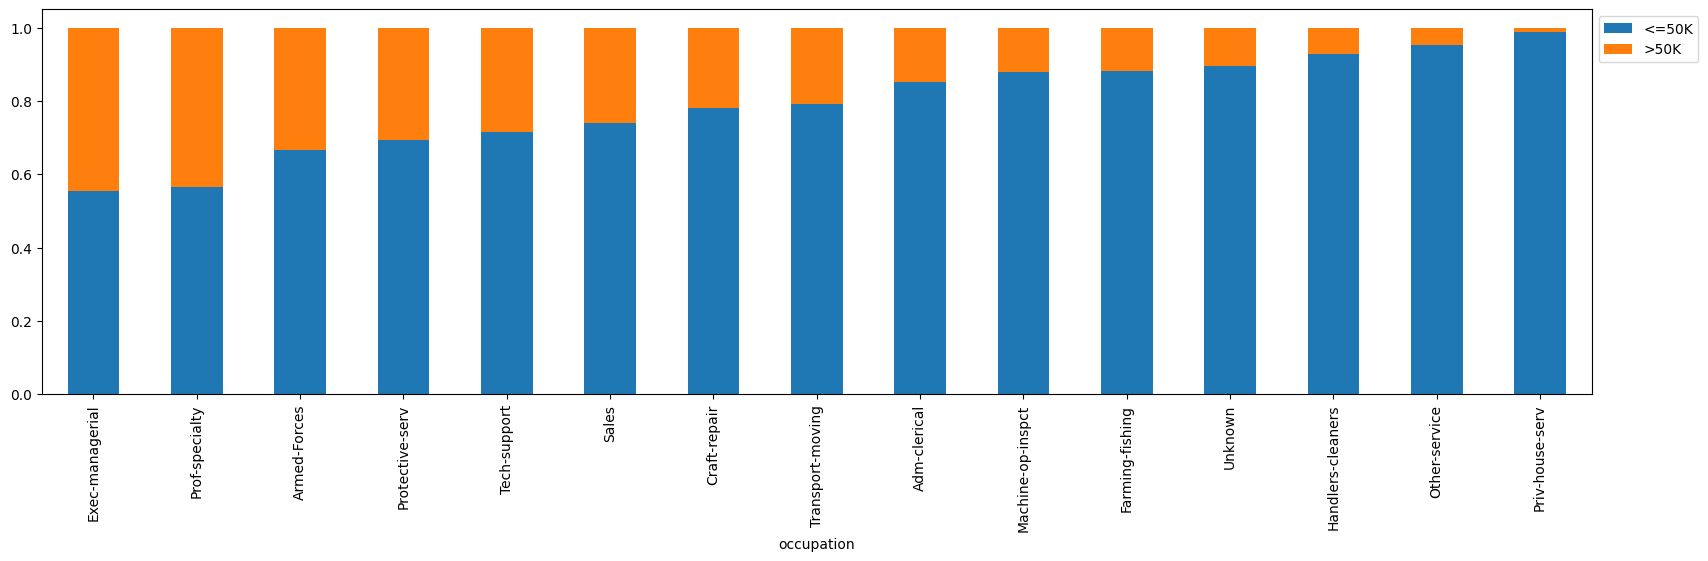

In [58]:
stacked_barplot(df, 'occupation', 'income')

<b>Observation:</b> There are many unique values here, so conclusions are hard to make, however, it is worth noting that occupations which require higher educations appear to have higher incomes, on average. Additionally, those in the armed forces have a considerably high average income, when compared to other occupations.

#### Visualizing relationship correlation with income

income          <=50K  >50K    All
relationship                      
All             31472  9610  41082
Husband          8725  6863  15588
Not-in-family    9974  1252  11226
Wife             1183  1025   2208
Unmarried        4551   307   4858
Own-child        5619   111   5730
Other-relative   1420    52   1472
------------------------------------------------------------------------------------------------------------------------


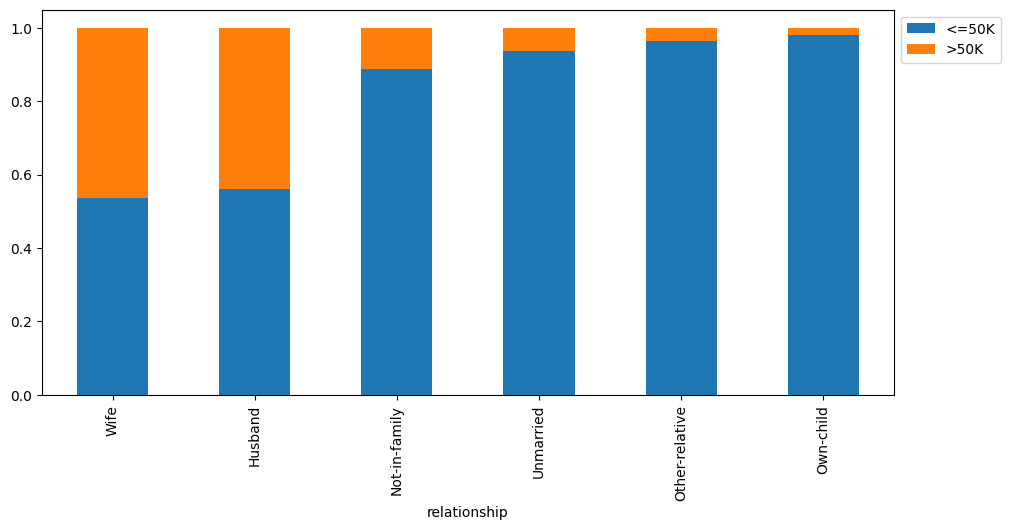

In [59]:
stacked_barplot(df, 'relationship', 'income')

<b>Observation:</b> Consistent with observations on the 'marital-status' column, individuals who are in an active marriage appear to have higher average incomes than those who aren't. Unsure if this is because the incomes of married people are combined, or if there is another reason.

#### Visualizing race correlation with income

income              <=50K  >50K    All
race                                  
All                 31472  9610  41082
White               25632  8544  34176
Black                3964   554   4518
Asian-Pac-Islander   1106   407   1513
Amer-Indian-Eskimo    414    55    469
Other                 356    50    406
------------------------------------------------------------------------------------------------------------------------


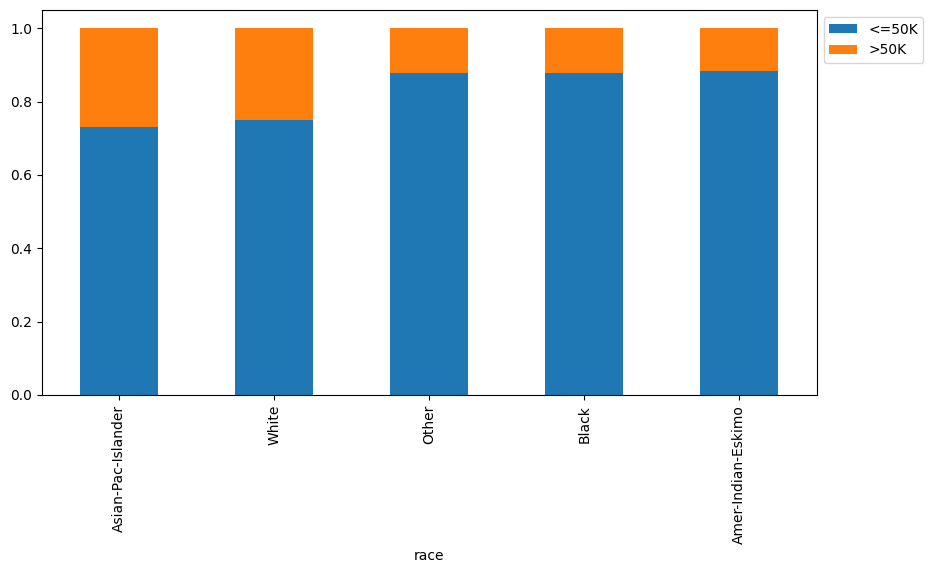

In [60]:
stacked_barplot(df, 'race', 'income')

<b>Observation:</b> Individuals who classify as 'asian-pac-islander' or 'white' have slightly higher average income than the other three race categories.

#### Visualizing gender correlation with income

income  <=50K  >50K    All
gender                    
All     31472  9610  41082
Male    18868  7918  26786
Female  12604  1692  14296
------------------------------------------------------------------------------------------------------------------------


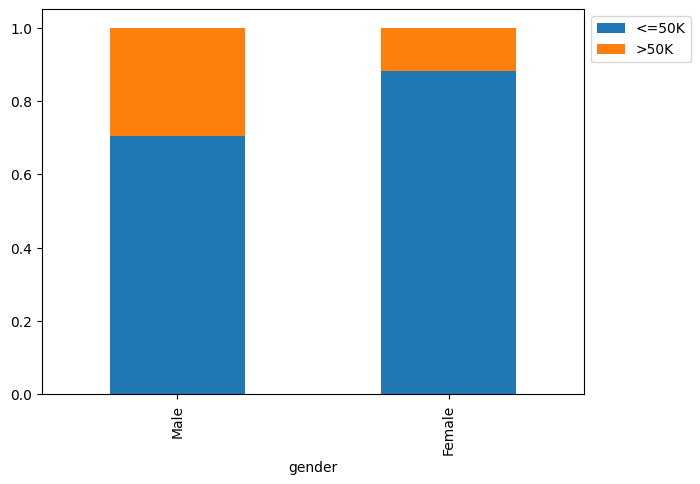

In [61]:
stacked_barplot(df, 'gender', 'income')

<b>Observation:</b> Individuals classified as male have a considerably higher average income than those who are classified as female.

#### Visualizing hours-per-week correlation with income

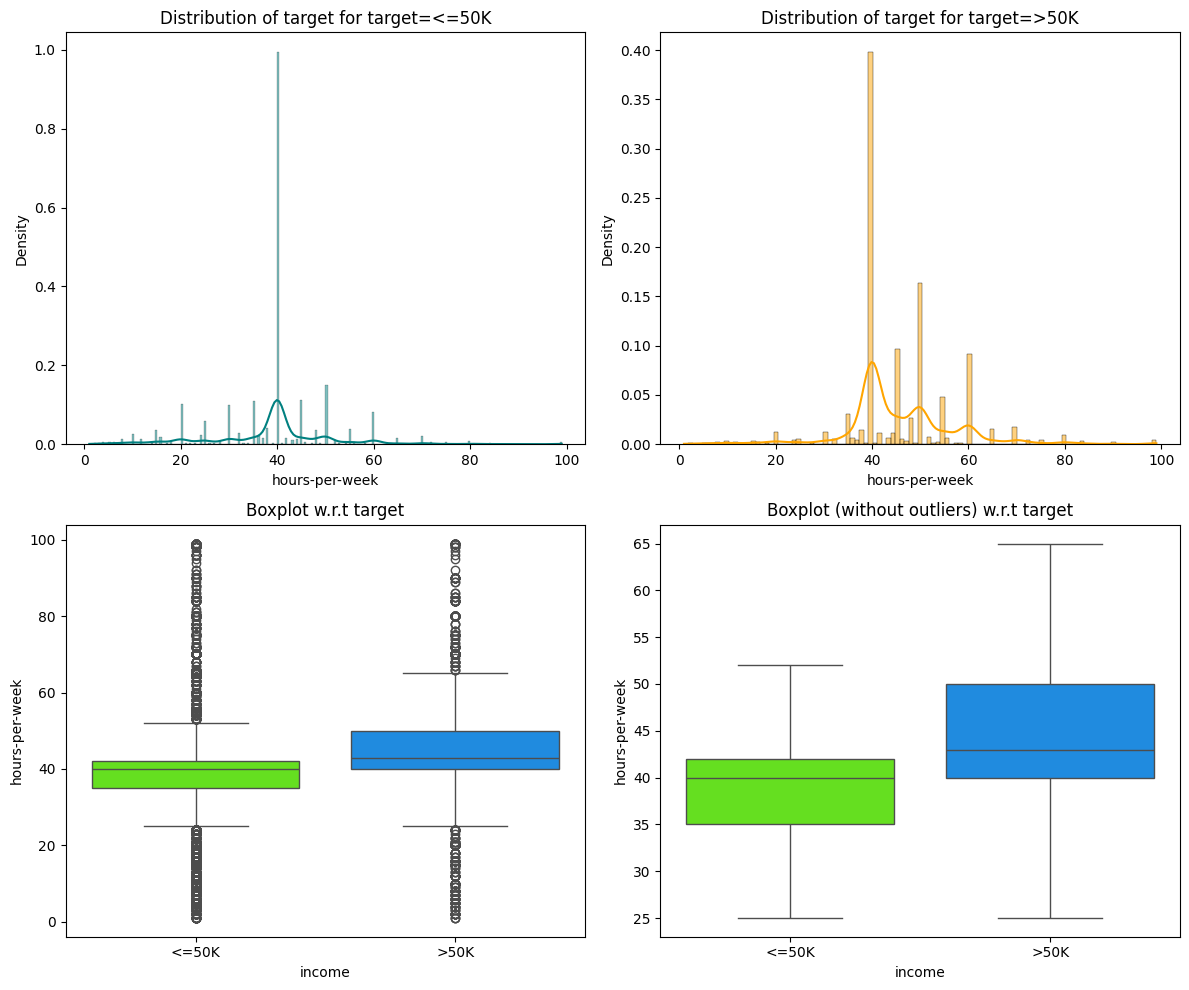

In [62]:
distribution_plot_wrt_target(df, 'hours-per-week', 'income')

<b>Observation:</b> Unsurprisingly, most of the data is accumulated at 40 hours per week, due to the sheer number of rows with this value. However, there is a considerably greater number of individuals working over 40 hours per week in the grouping of those with incomes above 50k.

#### Visualizing native-country correlation with income

income                      <=50K  >50K    All
native-country                                
All                         31472  9610  41082
United-States               27493  8621  36114
Unknown                       635   218    853
Philippines                   208    84    292
Canada                        119    63    182
India                          89    62    151
Germany                       147    58    205
Mexico                        877    47    924
England                        80    47    127
China                          86    36    122
Italy                          70    34    104
Cuba                          104    34    138
Japan                          60    32     92
Taiwan                         39    25     64
Iran                           37    22     59
South                          95    20    115
Puerto-Rico                   164    20    184
Greece                         31    18     49
Poland                         70    17     87
France       

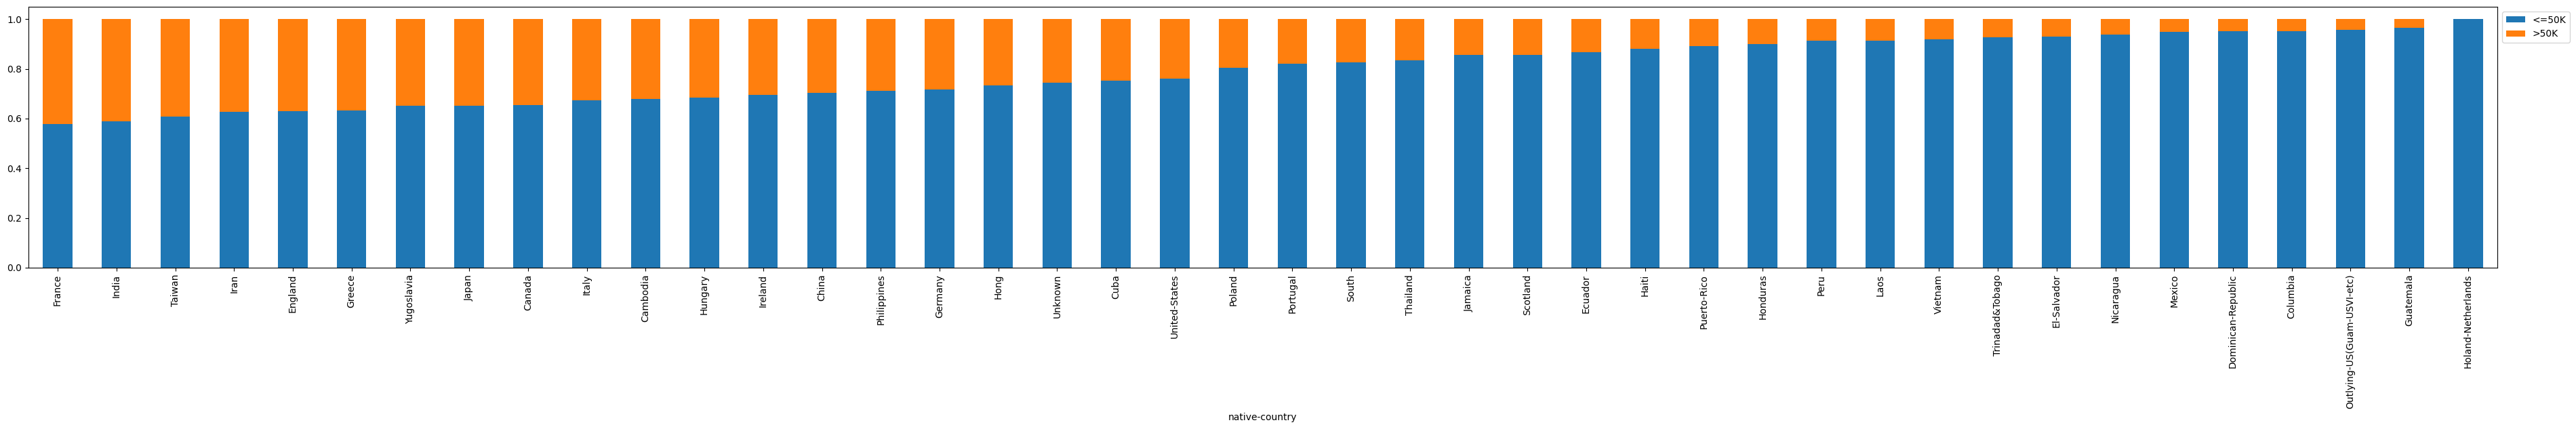

In [63]:
stacked_barplot(df, 'native-country', 'income')

<b>Observations:</b>
<ul>
    <li>First world countries dominate the left half of the graph</li>
    <li>Interestingly, the United States is middle of the pack, despite having by far the largest number of individuals with incomes above 50k</li>
    <li>Could be helpful to group countries into continent, due to the difficulty to draw specific conclusions</li>
</ul>

### Conclusions

Unsurprisingly, the most consistent predictors appear to be <b>hours-per-week</b>, and <b>education</b>, as there were very clear indications that more hours and/or higher education will lead to a higher income, on average.

There are also clear indications that being married leads to a higher income, on average, but I'm unsure if this is simply because married individuals' incomes are combined, or if there is some other reason for this.

Other notable trends include:
<ul>
    <li>Asian > White > Others for predicting higher income</li>
    <li>Male > Female for predicting higher income</li>
    <li>First world country > Non-first world country for predicting higher income</li>
</ul>

## Feature Engineering

### Categorical Features

#### COMPLETE: Perform feature engineering techniques to prepare the dataset for model building
Consider using the following feature engineering techniques:
- encoding categorical/object features
- scaling numeric features
- binning numeric features
- adding, deleting, combining features 
- check and address dependent variable imbalance (I will provide information on this aspect later in Week 5)

Some of the feature engineering techniques may not need to be applied to the dataset but you should at least consider them.

A few suggestions/hints:
- dependent variable should be converted to 0,1 values
- consolidate values when appropriate for some of the object variables
- convert native-country data to continent data
- if there are redundant features, reduce to one feature

#### Education

Since there are two education columns, which are functionally identical, I will be dropping the categorical version, for simplicity.

In [64]:
df = df.drop(['education'], axis=1)

#### Gender

Since there are only two values present in the dataframe for this column, it would be simpler to reduce this to a boolean value.

In [65]:
df = pd.get_dummies(df, columns=['gender'], drop_first=True)

In [66]:
df.head(10)

,age,workclass,educational-num,marital-status,occupation,relationship,race,hours-per-week,native-country,income,gender_Male
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,40,United-States,<=50K,True
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,50,United-States,<=50K,True
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,40,United-States,>50K,True
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,40,United-States,>50K,True
4,18,Unknown,10,Never-married,Unknown,Own-child,White,30,United-States,<=50K,False
5,34,Private,6,Never-married,Other-service,Not-in-family,White,30,United-States,<=50K,True
6,29,Unknown,9,Never-married,Unknown,Unmarried,Black,40,United-States,<=50K,True
7,63,Self-emp-not-inc,15,Married-civ-spouse,Prof-specialty,Husband,White,32,United-States,>50K,True
8,24,Private,10,Never-married,Other-service,Unmarried,White,40,United-States,<=50K,False
9,55,Private,4,Married-civ-spouse,Craft-repair,Husband,White,10,United-States,<=50K,True


#### Marital-status and relationship

While there are a handful of different values for marital-status, there is little difference in the income statistics between them, aside from the separation of those who are married and those who aren't. For that reason, this column will be consolidated into "married", "not-married", and "absent-spouse". It is worth noting that 'separated' technically indicates that the couple is still married, and could reconcile, however, due to the parallels between the indications of income between those individuals and those who are divorced, they are going to be considered not married.

Additionally, due to the obvious parallels between relationship/marital-status and relationship/gender, relationship will simply be consolidated into marital-status.

In [67]:
df['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
       'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [68]:
df.loc[df['marital-status'] == 'Married-civ-spouse', ['marital-status']] = 'Married'
df.loc[df['marital-status'] == 'Married-AF-spouse', ['marital-status']] = 'Married'
df.loc[df['marital-status'] == 'Never-married', ['marital-status']] = 'Not-married'
df.loc[df['marital-status'] == 'Widowed', ['marital-status']] = 'Not-married'
df.loc[df['marital-status'] == 'Divorced', ['marital-status']] = 'Not-married'
df.loc[df['marital-status'] == 'Separated', ['marital-status']] = 'Not-married'
df = df.drop(['relationship'], axis=1)

In [69]:
df.head(10)

,age,workclass,educational-num,marital-status,occupation,race,hours-per-week,native-country,income,gender_Male
0,25,Private,7,Not-married,Machine-op-inspct,Black,40,United-States,<=50K,True
1,38,Private,9,Married,Farming-fishing,White,50,United-States,<=50K,True
2,28,Local-gov,12,Married,Protective-serv,White,40,United-States,>50K,True
3,44,Private,10,Married,Machine-op-inspct,Black,40,United-States,>50K,True
4,18,Unknown,10,Not-married,Unknown,White,30,United-States,<=50K,False
5,34,Private,6,Not-married,Other-service,White,30,United-States,<=50K,True
6,29,Unknown,9,Not-married,Unknown,Black,40,United-States,<=50K,True
7,63,Self-emp-not-inc,15,Married,Prof-specialty,White,32,United-States,>50K,True
8,24,Private,10,Not-married,Other-service,White,40,United-States,<=50K,False
9,55,Private,4,Married,Craft-repair,White,10,United-States,<=50K,True


Upon further consideration, since there are now only three values, this column will be label encoded.

In [70]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['marital-status'] = label_encoder.fit_transform(df['marital-status'])

In [71]:
df.head(10)

,age,workclass,educational-num,marital-status,occupation,race,hours-per-week,native-country,income,gender_Male
0,25,Private,7,2,Machine-op-inspct,Black,40,United-States,<=50K,True
1,38,Private,9,0,Farming-fishing,White,50,United-States,<=50K,True
2,28,Local-gov,12,0,Protective-serv,White,40,United-States,>50K,True
3,44,Private,10,0,Machine-op-inspct,Black,40,United-States,>50K,True
4,18,Unknown,10,2,Unknown,White,30,United-States,<=50K,False
5,34,Private,6,2,Other-service,White,30,United-States,<=50K,True
6,29,Unknown,9,2,Unknown,Black,40,United-States,<=50K,True
7,63,Self-emp-not-inc,15,0,Prof-specialty,White,32,United-States,>50K,True
8,24,Private,10,2,Other-service,White,40,United-States,<=50K,False
9,55,Private,4,0,Craft-repair,White,10,United-States,<=50K,True


In [72]:
df['native-country'].unique()

array(['United-States', 'Unknown', 'Peru', 'Guatemala', 'Mexico',
       'Dominican-Republic', 'Ireland', 'Germany', 'Philippines',
       'Thailand', 'Haiti', 'El-Salvador', 'Puerto-Rico', 'Vietnam',
       'South', 'Columbia', 'Japan', 'India', 'Cambodia', 'Poland',
       'Laos', 'England', 'Cuba', 'Taiwan', 'Italy', 'Canada', 'Portugal',
       'China', 'Nicaragua', 'Honduras', 'Iran', 'Scotland', 'Jamaica',
       'Ecuador', 'Yugoslavia', 'Hungary', 'Hong', 'Greece',
       'Trinadad&Tobago', 'Outlying-US(Guam-USVI-etc)', 'France',
       'Holand-Netherlands'], dtype=object)

#### Native-country

Due to the large number of unique values, and the difficulty of drawing any notable conclusions between each similar, but unique value, it was considered that the values for this column should be grouped by continent. However, there is a stark difference in the potential income between many countries that share a continent. For example, many countries in the Caribbean islands are technically part of North America, but most definitely do not have similar average incomes as the United States or Canada.

Because of this, I was more tempted to group the countries by region instead (e.g. caribbean, central america, etc.), but this provides limited value to the column, as there would end up being a large number of different regions. For that reason, the column will be left as-is.

### Numerical Features

#### Age

Age will be scaled using Min-Max Scaling, rather than standardization due to its superior resistance to outliers, of which there are a few in the column.

In [73]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(df[['age']])
df[['age']] = scaler.transform(df[['age']])

In [74]:
df.head(10)

,age,workclass,educational-num,marital-status,occupation,race,hours-per-week,native-country,income,gender_Male
0,0.109589,Private,7,2,Machine-op-inspct,Black,40,United-States,<=50K,True
1,0.287671,Private,9,0,Farming-fishing,White,50,United-States,<=50K,True
2,0.150685,Local-gov,12,0,Protective-serv,White,40,United-States,>50K,True
3,0.369863,Private,10,0,Machine-op-inspct,Black,40,United-States,>50K,True
4,0.013699,Unknown,10,2,Unknown,White,30,United-States,<=50K,False
5,0.232877,Private,6,2,Other-service,White,30,United-States,<=50K,True
6,0.164384,Unknown,9,2,Unknown,Black,40,United-States,<=50K,True
7,0.630137,Self-emp-not-inc,15,0,Prof-specialty,White,32,United-States,>50K,True
8,0.095890,Private,10,2,Other-service,White,40,United-States,<=50K,False
9,0.520548,Private,4,0,Craft-repair,White,10,United-States,<=50K,True


#### Hours-per-week

Hours-per-week will also be scaled using Min-Max Scaling, rather than standardization due to its superior resistance to outliers, of which there are a few in the column.

In [75]:
scaler.fit(df[['hours-per-week']])
df[['hours-per-week']] = scaler.transform(df[['hours-per-week']])

In [76]:
df.head(10)

,age,workclass,educational-num,marital-status,occupation,race,hours-per-week,native-country,income,gender_Male
0,0.109589,Private,7,2,Machine-op-inspct,Black,0.397959,United-States,<=50K,True
1,0.287671,Private,9,0,Farming-fishing,White,0.500000,United-States,<=50K,True
2,0.150685,Local-gov,12,0,Protective-serv,White,0.397959,United-States,>50K,True
3,0.369863,Private,10,0,Machine-op-inspct,Black,0.397959,United-States,>50K,True
4,0.013699,Unknown,10,2,Unknown,White,0.295918,United-States,<=50K,False
5,0.232877,Private,6,2,Other-service,White,0.295918,United-States,<=50K,True
6,0.164384,Unknown,9,2,Unknown,Black,0.397959,United-States,<=50K,True
7,0.630137,Self-emp-not-inc,15,0,Prof-specialty,White,0.316327,United-States,>50K,True
8,0.095890,Private,10,2,Other-service,White,0.397959,United-States,<=50K,False
9,0.520548,Private,4,0,Craft-repair,White,0.091837,United-States,<=50K,True
